# 06 Compute Budget Tradeoff

This notebook compares TOAH and AO under different compute budgets.

Input: `result/table/06_compute_budget_tradeoff.csv`

Outputs: PDF figures in `result/figure/` and aggregated tables in `result/table/`.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------------------------
# Fix: Handle paths for both Script (.py) and Jupyter Notebook (.ipynb)
# -----------------------------------------------------------------------------
try:
    # This works when running as a script
    current_path = Path(__file__).resolve()
    ROOT = current_path.parents[1]
except NameError:
    # This works in Jupyter Notebook
    # Note: Path.cwd() returns the directory where the notebook is running.
    # If your notebook is in "root/src/", .parents[0] gives "root/"
    # Adjust the number of parents based on your folder structure.
    current_path = Path.cwd()
    ROOT = current_path.parents[0]  # Change [0] to [1] if needed based on notebook location

# Verify the path is correct
print(f"Current ROOT: {ROOT}")

tbl_dir = ROOT / "result" / "table"
fig_dir = ROOT / "result" / "figure"
fig_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Load Data
# -----------------------------------------------------------------------------
# Ensure the file exists before reading to avoid FileNotFoundError
csv_path = tbl_dir / "06_compute_budget_tradeoff.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(df.head())
else:
    print(f"Error: File not found at {csv_path}")

Current ROOT: /home/leiyo/GitHub/TOAH
   seed        method  avg_sum_queue  p95_max_queue  avg_sense_u  p95_sense_u  \
0   123          TOAH     944.702881     588.994385    88.706856   227.376999   
1   123  AO-Heuristic     944.701721     588.996826    12.191405    39.131367   
2   123  AO-Heuristic     944.701721     588.996826     9.622646    30.699301   
3   123  AO-Heuristic     944.701660     588.996826     5.790369    15.337078   
4   123  AO-Heuristic     944.701904     588.997314     4.015146     9.918715   

   alpha_total_variation  switch_count  deadline_violation_rate  avg_slot_ms  \
0                0.52301             1                     0.92  2918.786428   
1                1.00000             1                     0.92    28.106732   
2                1.00000             1                     0.92    42.482004   
3                1.00000             1                     0.92    64.351265   
4                1.00000             1                     0.92   108.73967

In [3]:
# Aggregate mean/std across runs per budget label
metrics = ["avg_sum_queue", "avg_sense_u", "deadline_violation_rate", "avg_slot_ms"]

agg = df.groupby(["budget"])[metrics].agg(["mean", "std"]).reset_index()
agg.columns = ["budget"] + [f"{m}_{s}" for m in metrics for s in ["mean", "std"]]

out_table = tbl_dir / "06_compute_budget_table.csv"
agg.to_csv(out_table, index=False)
print("Saved table:", out_table)

agg


Saved table: /home/leiyo/GitHub/TOAH/result/table/06_compute_budget_table.csv


,budget,avg_sum_queue_mean,avg_sum_queue_std,avg_sense_u_mean,avg_sense_u_std,deadline_violation_rate_mean,deadline_violation_rate_std,avg_slot_ms_mean,avg_slot_ms_std
0,AO-steps10,963.060282,20.837398,2.848019,2.707236,0.915833,0.003819,64.417440,0.518379
1,AO-steps2,963.060323,20.837405,6.609932,5.244232,0.915833,0.003819,27.973263,0.328634
2,AO-steps20,963.060303,20.837310,1.993746,1.883743,0.915833,0.003819,109.299157,0.579297
3,AO-steps40,963.059570,20.837409,1.451350,1.631010,0.915833,0.003819,198.735619,0.812680
4,AO-steps5,963.060384,20.837386,9.574180,8.688150,0.915833,0.003819,41.985301,0.430618
5,AO-steps80,963.057353,20.837534,0.666638,0.504218,0.915833,0.003819,377.849336,3.235190
6,TOAH-default,951.735931,9.946235,52.174423,51.664662,0.625833,0.503030,2918.225465,0.781930


Saved: /home/leiyo/GitHub/TOAH/result/figure/06_scatter_runtime_vs_queue.pdf


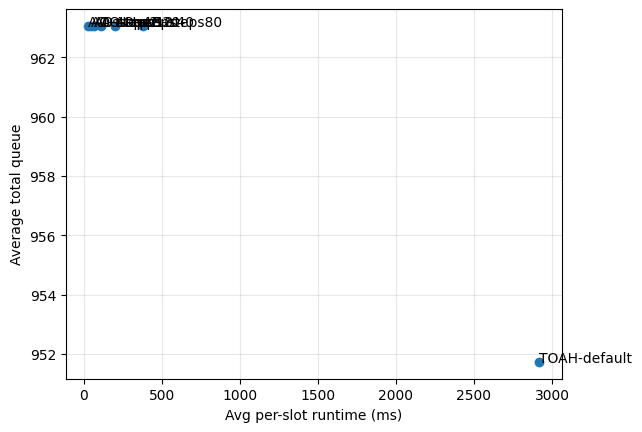

In [4]:
# Scatter: runtime vs performance (queue)
plt.figure()
plt.scatter(agg["avg_slot_ms_mean"], agg["avg_sum_queue_mean"])
for _, r in agg.iterrows():
    plt.annotate(r["budget"], (r["avg_slot_ms_mean"], r["avg_sum_queue_mean"]))
plt.xlabel("Avg per-slot runtime (ms)")
plt.ylabel("Average total queue")
plt.grid(True, alpha=0.3)
out = fig_dir / "06_scatter_runtime_vs_queue.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/06_scatter_runtime_vs_sense_u.pdf


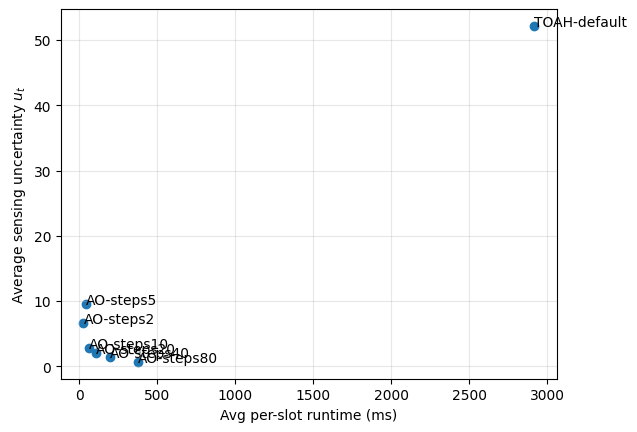

In [5]:
# Scatter: runtime vs sensing
plt.figure()
plt.scatter(agg["avg_slot_ms_mean"], agg["avg_sense_u_mean"])
for _, r in agg.iterrows():
    plt.annotate(r["budget"], (r["avg_slot_ms_mean"], r["avg_sense_u_mean"]))
plt.xlabel("Avg per-slot runtime (ms)")
plt.ylabel("Average sensing uncertainty $u_t$")
plt.grid(True, alpha=0.3)
out = fig_dir / "06_scatter_runtime_vs_sense_u.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/06_line_ao_steps_vs_queue.pdf
Saved: /home/leiyo/GitHub/TOAH/result/figure/06_line_ao_steps_vs_sense_u.pdf


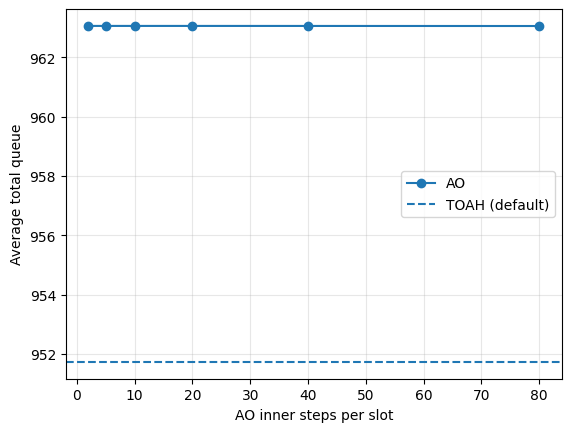

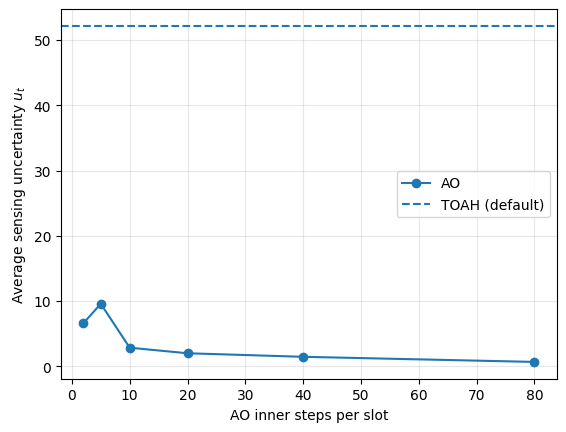

In [6]:
# Line: AO performance vs budget, with TOAH as a reference line
toah_row = agg[agg["budget"] == "TOAH-default"].iloc[0]
ao_rows = agg[agg["budget"].str.startswith("AO-")].copy()
ao_rows["steps"] = ao_rows["budget"].str.replace("AO-steps", "", regex=False).astype(int)
ao_rows = ao_rows.sort_values("steps")

plt.figure()
plt.plot(ao_rows["steps"], ao_rows["avg_sum_queue_mean"], marker="o", label="AO")
plt.axhline(toah_row["avg_sum_queue_mean"], linestyle="--", label="TOAH (default)")
plt.xlabel("AO inner steps per slot")
plt.ylabel("Average total queue")
plt.legend()
plt.grid(True, alpha=0.3)
out = fig_dir / "06_line_ao_steps_vs_queue.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)

plt.figure()
plt.plot(ao_rows["steps"], ao_rows["avg_sense_u_mean"], marker="o", label="AO")
plt.axhline(toah_row["avg_sense_u_mean"], linestyle="--", label="TOAH (default)")
plt.xlabel("AO inner steps per slot")
plt.ylabel("Average sensing uncertainty $u_t$")
plt.legend()
plt.grid(True, alpha=0.3)
out = fig_dir / "06_line_ao_steps_vs_sense_u.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/06_bar_deadline_violation.pdf


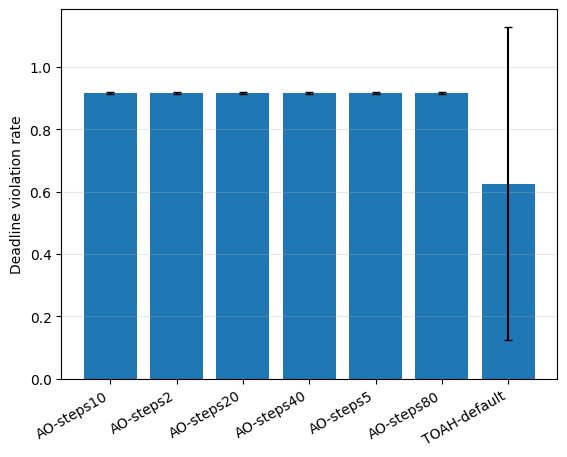

In [7]:
# Bar: deadline violation rate vs budget
labels = list(agg["budget"])
vals = agg["deadline_violation_rate_mean"].values
errs = agg["deadline_violation_rate_std"].values

plt.figure()
plt.bar(range(len(labels)), vals, yerr=errs, capsize=3)
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.ylabel("Deadline violation rate")
plt.grid(True, axis="y", alpha=0.3)
out = fig_dir / "06_bar_deadline_violation.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)
